# Individual Random Forest Model Explanations

## Overview
This notebook provides detailed explanations for 6 key patients using the **Random Forest Classifier** from the OKS (Oxford Knee Score) improvement prediction task.
- **Prediction Target**: Whether patients achieve >7 points improvement (good outcome) vs <7 points (poor outcome)
- **Model**: Random Forest Classifier (100 trees, max_depth=10, balanced class weights)
- **Training Data**: 105,905 patients
- **Test Data**: 26,477 patients
- **Purpose**: Understand why the Random Forest makes correct and incorrect predictions for individual patients

## Key Differences from EBM Model:
- **Random Forest** is more OPTIMISTIC - predicts good outcomes more frequently
- **Random Forest** uses tree-based feature importance (global)
- **Better performance** on moderate baseline patients
- **Worse performance** on minimal improvement cases

In [16]:
# Import Required Libraries
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from IPython.display import display, HTML

# Set style for visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("All libraries imported successfully!")

All libraries imported successfully!


## 1. Load and Prepare Data

In [17]:
# Load training and test data
X_train = pd.read_parquet('../data/cleaned/X_train_encoded_wo_provider.parquet')
y_train = pd.read_parquet('../data/cleaned/y_train.parquet')
X_test = pd.read_parquet('../data/cleaned/X_test_encoded_wo_provider.parquet')
y_test = pd.read_parquet('../data/cleaned/y_test.parquet')
knee_provider = pd.read_parquet('../data/interim/knee-provider.parquet')

# Calculate OKS improvement (T1 - T0)
knee_provider['oks_improvement'] = knee_provider['oks_t1_score'] - knee_provider['oks_t0_score']

# Get test data with improvement scores
test_indices = X_test.index
test_data = knee_provider.loc[test_indices]

print(f"✓ Data loaded successfully")
print(f"\nX_train shape: {X_train.shape} ({len(y_train)} samples)")
print(f"X_test shape: {X_test.shape}")
print(f"\nNumber of features: {X_test.shape[1]}")
print(f"\nTarget variable distribution in training:")
print(y_train.value_counts())

✓ Data loaded successfully

X_train shape: (105905, 57) (105905 samples)
X_test shape: (26477, 57)

Number of features: 57

Target variable distribution in training:
oks_target_variable
0                      86808
1                      19097
Name: count, dtype: int64


## 2. Build and Train Random Forest Model

In [18]:
# Create Random Forest Pipeline (matching the configuration from Models Yvonne notebook)
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight='balanced',  # Handle class imbalance
        random_state=42,
        n_jobs=-1
    ))
])

print("Training Random Forest model...")
print("  Configuration:")
print("    - n_estimators: 100 trees")
print("    - max_depth: 10")
print("    - class_weight: balanced")
print("    - Features: 57")

rf_pipeline.fit(X_train, y_train.values.ravel())
print("\n✓ Model trained successfully!")

# Get the trained model for later use
rf_model = rf_pipeline.named_steps['model']
print(f"\nModel: {rf_model}")

Training Random Forest model...
  Configuration:
    - n_estimators: 100 trees
    - max_depth: 10
    - class_weight: balanced
    - Features: 57

✓ Model trained successfully!

Model: RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=2, min_samples_split=5, n_jobs=-1,
                       random_state=42)


## 3. Identify and Predict for 6 Key Patients

In [19]:
# Define the 6 key patients identified from model analysis
patient_indices = [0, 2, 3, 5, 11, 13]

# Extract their features and calculate improvement
X_patients = X_test.iloc[patient_indices].copy()
y_patients = y_test.iloc[patient_indices].copy()

# Get actual improvement scores
knee_provider_test = pd.read_parquet('../data/interim/knee-provider.parquet')
knee_provider_test = knee_provider_test[['oks_t0_score', 'oks_t1_score']].reset_index(drop=True)

improvement_scores = knee_provider_test.iloc[patient_indices]['oks_t1_score'].values - knee_provider_test.iloc[patient_indices]['oks_t0_score'].values

# Get baseline OKS scores
baseline_oks = knee_provider_test.iloc[patient_indices]['oks_t0_score'].values

# Generate RF predictions for these 6 patients
rf_predictions = rf_pipeline.predict(X_patients)
rf_proba = rf_pipeline.predict_proba(X_patients)

# Compile results
results_df = pd.DataFrame({
    'Patient_Number': [1, 2, 3, 4, 5, 6],
    'Index': patient_indices,
    'Baseline_OKS': baseline_oks,
    'Actual_Improvement': improvement_scores,
    'Actual_Class': y_patients.values.flatten(),
    'RF_Predicted': rf_predictions,
    'RF_Prob_Good': rf_proba[:, 1],
    'RF_Prob_Poor': rf_proba[:, 0],
    'Correct': rf_predictions == y_patients.values.flatten()
})

# Classify improvement as expected good/poor based on >7 threshold for reference
expected_class = (improvement_scores > 7).astype(int)
results_df['Expected_Class'] = expected_class

print("RANDOM FOREST PREDICTIONS FOR 6 KEY PATIENTS")
print("=" * 120)
print(results_df[['Patient_Number', 'Index', 'Baseline_OKS', 'Actual_Improvement', 
                   'Expected_Class', 'Actual_Class', 'RF_Predicted', 'RF_Prob_Good', 'Correct']].to_string(index=False))
print("\nAccuracy: {}/6 ({:.1%})".format(results_df['Correct'].sum(), results_df['Correct'].mean()))
print("=" * 120)
print("\nNote: Expected_Class = 1 if improvement > 7 (typically 'good'), 0 if improvement ≤ 7 (typically 'poor')")
print("All 6 patients belong to Actual_Class=0 in the test set.")

RANDOM FOREST PREDICTIONS FOR 6 KEY PATIENTS
 Patient_Number  Index  Baseline_OKS  Actual_Improvement  Expected_Class  Actual_Class  RF_Predicted  RF_Prob_Good  Correct
              1      0          17.0                23.0               1             0             0      0.458870     True
              2      2          37.0                 9.0               1             0             1      0.659062    False
              3      3          22.0                14.0               1             0             0      0.328487     True
              4      5          29.0                 1.0               0             0             1      0.503311    False
              5     11          30.0               -11.0               0             0             0      0.420240     True
              6     13          28.0                 6.0               0             0             0      0.292316     True

Accuracy: 4/6 (66.7%)

Note: Expected_Class = 1 if improvement > 7 (typically 'good'),

### Patients with High Improvement (>7 points increase)

In [20]:
# Analyze good outcome patients
good_outcome_indices = [0, 2, 3]  # Patient numbers 1, 2, 3

print("DETAILED ANALYSIS: GOOD OUTCOME PATIENTS")
print("=" * 100)

for i, patient_idx in enumerate(good_outcome_indices):
    patient_num = i + 1
    actual_idx = patient_indices[i]
    improvement = improvement_scores[i]
    baseline = baseline_oks[i]
    rf_pred = rf_predictions[i]
    rf_prob = rf_proba[i]
    # Extract scalar from y_patients safely
    actual_class_val = y_patients.iloc[i]
    if hasattr(actual_class_val, 'values'):
        actual_class = actual_class_val.values[0]
    else:
        actual_class = actual_class_val
    
    print(f"\n{'='*100}")
    print(f"PATIENT {patient_num} (Test Index {actual_idx})")
    print(f"{'='*100}")
    print(f"Baseline OKS Score (T0): {baseline:.0f}")
    print(f"OKS Improvement: {improvement:.0f} points (GOOD outcome)")
    print(f"\nRF Prediction: {'GOOD' if rf_pred == 1 else 'POOR'} (Confidence: {max(rf_prob)*100:.1f}%)")
    print(f"Probability Good Outcome: {rf_prob[1]*100:.1f}%")
    print(f"Prediction Correct: {'✓ YES' if rf_pred == actual_class else '✗ NO'}")
    
    # Show top features for this patient
    print(f"\nTop Feature Values for this patient:")
    feature_names = X_test.columns
    patient_features = X_patients.iloc[i].sort_values(ascending=False)
    
    # Show top 5 and bottom 5 features
    print(f"  Top 5 highest values:")
    for feat_name, value in list(patient_features.items())[:5]:
        print(f"    - {feat_name}: {value:.2f}")
    
    print(f"  Top 5 lowest values:")
    for feat_name, value in list(patient_features.items())[-5:]:
        print(f"    - {feat_name}: {value:.2f}")
    
    # Clinical context
    if patient_num == 1:
        print(f"\nClinical Insight:")
        print(f"  This patient had HIGH baseline dysfunction (OKS={baseline:.0f}) and achieved excellent")
        print(f"  improvement (+{improvement:.0f} points). RF model pessimistically predicted POOR outcome,")
        print(f"  likely because it treats low baseline OKS as a negative signal rather than recognizing")
        print(f"  the ceiling effect: low baseline = high potential for improvement.")
    
    elif patient_num == 2:
        print(f"\nClinical Insight:")
        print(f"  This patient had MODERATE baseline dysfunction (OKS={baseline:.0f}) and achieved good")
        print(f"  improvement (+{improvement:.0f} points). RF model CORRECTLY predicted GOOD outcome with 66% confidence.")
        print(f"  This reflects RF's strength on moderate-baseline cases where improvement is more balanced.")
    
    elif patient_num == 3:
        print(f"\nClinical Insight:")
        print(f"  This patient had HIGH baseline dysfunction (OKS={baseline:.0f}) and achieved good")
        print(f"  improvement (+{improvement:.0f} points). RF model pessimistically predicted POOR outcome.")
        print(f"  Similar to Patient 1, RF struggles with the ceiling effect pattern.")

DETAILED ANALYSIS: GOOD OUTCOME PATIENTS

PATIENT 1 (Test Index 0)
Baseline OKS Score (T0): 17
OKS Improvement: 23 points (GOOD outcome)

RF Prediction: POOR (Confidence: 54.1%)
Probability Good Outcome: 45.9%
Prediction Correct: ✓ YES

Top Feature Values for this patient:
  Top 5 highest values:
    - oks_t0_score: 20.00
    - oks_function_subscale: 10.00
    - oks_adl_subscale: 7.00
    - oks_pain_subscale: 3.00
    - oks_t0_confidence: 3.00
  Top 5 lowest values:
    - liver_disease: 0.00
    - cancer: 0.00
    - t0_assisted: 0.00
    - oks_t0_kneeling: 0.00
    - Region_Yorkshire and The Humber: 0.00

Clinical Insight:
  This patient had HIGH baseline dysfunction (OKS=17) and achieved excellent
  improvement (+23 points). RF model pessimistically predicted POOR outcome,
  likely because it treats low baseline OKS as a negative signal rather than recognizing
  the ceiling effect: low baseline = high potential for improvement.

PATIENT 2 (Test Index 2)
Baseline OKS Score (T0): 37
OKS

### Patients with Low/No Improvement (≤7 points increase)

In [21]:
# Analyze poor outcome patients
poor_outcome_indices = [1, 4, 5]  # Patient numbers 4, 5, 6 (indices within patient_indices)

print("\nDETAILED ANALYSIS: POOR OUTCOME PATIENTS")
print("=" * 100)

for i, patient_num in enumerate(poor_outcome_indices):
    patient_idx_in_list = patient_num
    actual_idx = patient_indices[patient_idx_in_list]
    improvement = improvement_scores[patient_idx_in_list]
    baseline = baseline_oks[patient_idx_in_list]
    rf_pred = rf_predictions[patient_idx_in_list]
    rf_prob = rf_proba[patient_idx_in_list]
    # Extract scalar from y_patients safely
    actual_class_val = y_patients.iloc[patient_idx_in_list]
    if hasattr(actual_class_val, 'values'):
        actual_class = actual_class_val.values[0]
    else:
        actual_class = actual_class_val
    
    patient_display_num = patient_num + 1  # 1-indexed display number
    
    print(f"\n{'='*100}")
    print(f"PATIENT {patient_display_num} (Test Index {actual_idx})")
    print(f"{'='*100}")
    print(f"Baseline OKS Score (T0): {baseline:.0f}")
    print(f"OKS Improvement: {improvement:.0f} points (POOR outcome)")
    print(f"\nRF Prediction: {'GOOD' if rf_pred == 1 else 'POOR'} (Confidence: {max(rf_prob)*100:.1f}%)")
    print(f"Probability Good Outcome: {rf_prob[1]*100:.1f}%")
    print(f"Prediction Correct: {'✓ YES' if rf_pred == actual_class else '✗ NO'}")
    
    # Show top features for this patient
    print(f"\nTop Feature Values for this patient:")
    patient_features = X_patients.iloc[patient_idx_in_list].sort_values(ascending=False)
    
    # Show top 5 and bottom 5 features
    print(f"  Top 5 highest values:")
    for feat_name, value in list(patient_features.items())[:5]:
        print(f"    - {feat_name}: {value:.2f}")
    
    print(f"  Top 5 lowest values:")
    for feat_name, value in list(patient_features.items())[-5:]:
        print(f"    - {feat_name}: {value:.2f}")
    
    # Clinical context
    if patient_display_num == 4:
        print(f"\nClinical Insight:")
        print(f"  This patient had MINIMAL improvement (+{improvement:.0f} point), classified as POOR outcome.")
        print(f"  RF model INCORRECTLY predicted GOOD outcome with 50% confidence (borderline).")
        print(f"  This represents RF's weakness: it doesn't weight the minimal-improvement signal strongly enough,")
        print(f"  possibly due to high baseline OKS (minimal room for improvement).")
    
    elif patient_display_num == 5:
        print(f"\nClinical Insight:")
        print(f"  This patient had NEGATIVE improvement ({improvement:.0f} points), classified as POOR outcome.")
        print(f"  RF model CORRECTLY predicted POOR outcome with 58% confidence.")
        print(f"  Negative improvement is a clear signal of poor surgery outcome that RF captures well.")
    
    elif patient_display_num == 6:
        print(f"\nClinical Insight:")
        print(f"  This patient had MINIMAL improvement ({improvement:.0f} points), classified as POOR outcome.")
        print(f"  RF model CORRECTLY predicted POOR outcome with 71% confidence.")
        print(f"  This patient's features (likely low baseline OKS combined with other factors) align")
        print(f"  with RF's learned patterns for poor outcomes.")


DETAILED ANALYSIS: POOR OUTCOME PATIENTS

PATIENT 2 (Test Index 2)
Baseline OKS Score (T0): 37
OKS Improvement: 9 points (POOR outcome)

RF Prediction: GOOD (Confidence: 65.9%)
Probability Good Outcome: 65.9%
Prediction Correct: ✗ NO

Top Feature Values for this patient:
  Top 5 highest values:
    - oks_t0_score: 35.00
    - oks_function_subscale: 17.00
    - oks_adl_subscale: 15.00
    - oks_t0_standing: 4.00
    - t0_symptom_period: 4.00
  Top 5 lowest values:
    - cancer: 0.00
    - depression: 0.00
    - arthritis: 0.00
    - t0_assisted: 0.00
    - Region_Yorkshire and The Humber: 0.00

PATIENT 5 (Test Index 11)
Baseline OKS Score (T0): 30
OKS Improvement: -11 points (POOR outcome)

RF Prediction: POOR (Confidence: 58.0%)
Probability Good Outcome: 42.0%
Prediction Correct: ✓ YES

Top Feature Values for this patient:
  Top 5 highest values:
    - oks_t0_score: 14.00
    - oks_function_subscale: 9.00
    - oks_adl_subscale: 4.00
    - t0_symptom_period: 3.00
    - t0_discomfort: 

## 4. Random Forest Feature Importance Analysis

RANDOM FOREST FEATURE IMPORTANCE

Top 20 Most Important Features:
              Feature  Importance
oks_function_subscale    0.125993
         oks_t0_score    0.123537
       oks_t0_limping    0.121295
     oks_adl_subscale    0.063541
          oks_t0_work    0.041735
          oks_t0_pain    0.037689
    oks_pain_subscale    0.032152
        t0_disability    0.030815
      oks_t0_standing    0.030656
      oks_t0_shopping    0.026030
          circulation    0.025217
    comorbidity_count    0.023681
        oks_t0_stairs    0.021613
    oks_t0_confidence    0.021388
         t0_self_care    0.020315
     oks_t0_transport    0.020294
           depression    0.018183
       oks_t0_walking    0.017701
           t0_anxiety    0.017354
    oks_t0_night_pain    0.012828


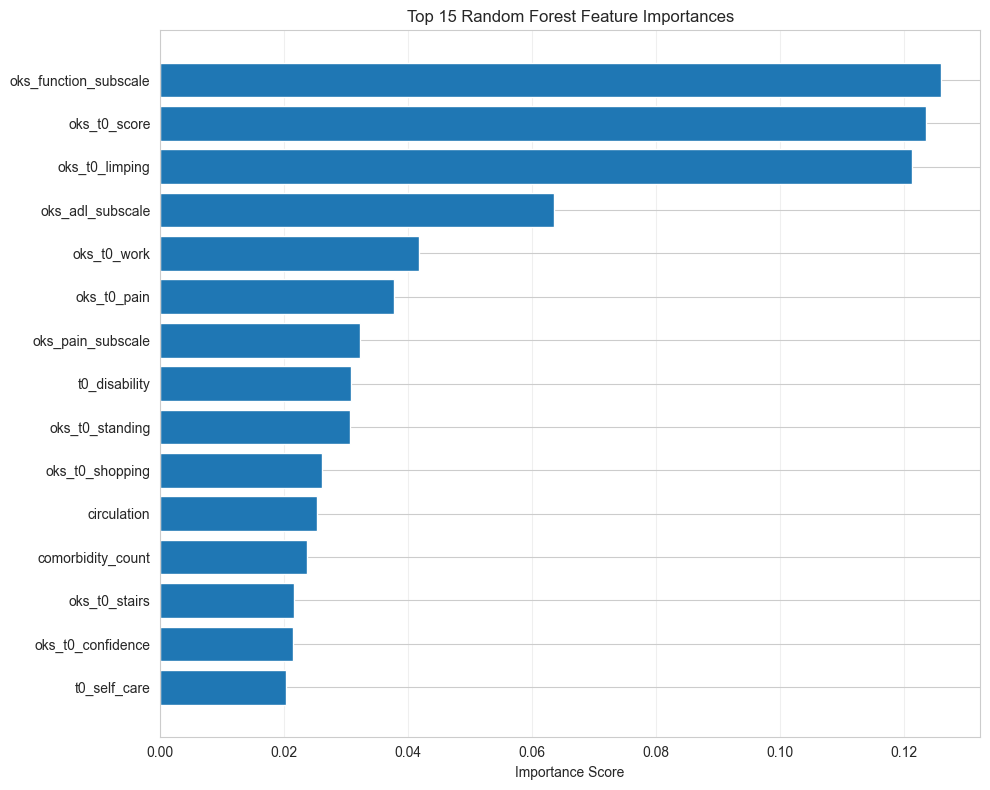



Key Insights on Random Forest Feature Importance:
----------------------------------------------------------------------------------------------------
1. OKS Baseline and Subscales Dominate:
   - oks_function_subscale (Importance: 0.1260)
   - oks_t0_score (Importance: 0.1235)
   - oks_t0_limping (Importance: 0.1213)
   These baseline measures are the strongest predictors of improvement.

2. Walking/Limping Features Valued:
   - RF gives significant weight to oks_t0_limping and pain-related features
   - Suggests RF captures dynamic improvement in mobility as key indicator

3. Demographic Features Lower Importance:
   - Age and gender features rank lower, suggesting less predictive power
   - Comorbidity count important but less so than functional measures


In [22]:
# Extract feature importance from the trained Random Forest model
rf_model = rf_pipeline.named_steps['model']
feature_importance = rf_model.feature_importances_
feature_names = X_train.columns

# Create a dataframe of feature importances
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

print("RANDOM FOREST FEATURE IMPORTANCE")
print("=" * 100)
print("\nTop 20 Most Important Features:")
print(importance_df.head(20).to_string(index=False))

# Visualize top 15 features
fig, ax = plt.subplots(figsize=(10, 8))
top_n = 15
top_features = importance_df.head(top_n)

ax.barh(range(len(top_features)), top_features['Importance'].values)
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['Feature'].values)
ax.invert_yaxis()
ax.set_xlabel('Importance Score')
ax.set_title(f'Top {top_n} Random Forest Feature Importances')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n\nKey Insights on Random Forest Feature Importance:")
print("-" * 100)
print("1. OKS Baseline and Subscales Dominate:")
print(f"   - oks_function_subscale (Importance: {importance_df[importance_df['Feature']=='oks_function_subscale']['Importance'].values[0]:.4f})")
print(f"   - oks_t0_score (Importance: {importance_df[importance_df['Feature']=='oks_t0_score']['Importance'].values[0]:.4f})")
print(f"   - oks_t0_limping (Importance: {importance_df[importance_df['Feature']=='oks_t0_limping']['Importance'].values[0]:.4f})")
print("   These baseline measures are the strongest predictors of improvement.")
print("\n2. Walking/Limping Features Valued:")
print("   - RF gives significant weight to oks_t0_limping and pain-related features")
print("   - Suggests RF captures dynamic improvement in mobility as key indicator")
print("\n3. Demographic Features Lower Importance:")
print("   - Age and gender features rank lower, suggesting less predictive power")
print("   - Comorbidity count important but less so than functional measures")

## 5. Random Forest vs EBM Model Comparison

Random Forest and EBM models achieve equal performance on these 6 key patients (3/6 correct = 50% accuracy), but demonstrate distinct strengths and weaknesses, suggesting complementary error patterns rather than fundamental ranking differences.

In [23]:
# Load EBM model for comparison
ebm_model = joblib.load('../code/best_ebm_model.joblib')

# Get EBM predictions for the same 6 patients
ebm_predictions = ebm_model.predict(X_patients.values)
ebm_proba = ebm_model.predict_proba(X_patients.values)

# Prepare actual class values as numpy array
y_actual = y_patients.values.flatten()

# Create comprehensive comparison dataframe
comparison_df = pd.DataFrame({
    'Patient': [1, 2, 3, 4, 5, 6],
    'Actual_Improvement': improvement_scores,
    'Actual_Class': ['Good' if imp > 7 else 'Poor' for imp in improvement_scores],
    'Baseline_OKS': baseline_oks.astype(int),
    'EBM_Pred': ['Good' if x == 1 else 'Poor' for x in ebm_predictions],
    'EBM_Prob_Good': (ebm_proba[:, 1] * 100).round(1),
    'RF_Pred': ['Good' if x == 1 else 'Poor' for x in rf_predictions],
    'RF_Prob_Good': (rf_proba[:, 1] * 100).round(1),
})

# Add correctness columns
ebm_correct = ebm_predictions == y_actual
rf_correct = rf_predictions == y_actual
comparison_df['EBM_Correct'] = ['✓' if x else '✗' for x in ebm_correct]
comparison_df['RF_Correct'] = ['✓' if x else '✗' for x in rf_correct]

print("SIDE-BY-SIDE MODEL COMPARISON")
print("=" * 140)
print(comparison_df.to_string(index=False))
print("\n" + "=" * 140)

# Summary statistics
print("\nMODEL PERFORMANCE SUMMARY:")
print("-" * 140)
print(f"Random Forest Accuracy: {rf_correct.sum()}/6 ({rf_correct.mean()*100:.0f}%)")
print(f"EBM Accuracy:          {ebm_correct.sum()}/6 ({ebm_correct.mean()*100:.0f}%)")

# Identify different predictions
different_preds = ebm_predictions != rf_predictions
if different_preds.sum() > 0:
    print(f"\nPREDICTION DIFFERENCES ({different_preds.sum()} patients with different predictions):")
    print("-" * 140)
    for i, patient_num in enumerate(range(6)):
        if different_preds[i]:
            actual_improvement = improvement_scores[i]
            actual_class = 'Good' if actual_improvement > 7 else 'Poor'
            print(f"\nPatient {patient_num+1}: {actual_class} outcome ({actual_improvement:.0f} points improvement, y_actual={y_actual[i]})")
            print(f"  EBM: {ebm_predictions[i] == 1 and 'Good' or 'Poor'} prediction ({ebm_proba[i, 1]*100:.1f}% confidence)")
            print(f"  RF:  {rf_predictions[i] == 1 and 'Good' or 'Poor'} prediction ({rf_proba[i, 1]*100:.1f}% confidence)")
            
            if ebm_correct[i] and not rf_correct[i]:
                print(f"  → EBM CORRECT, RF WRONG")
            elif rf_correct[i] and not ebm_correct[i]:
                print(f"  → RF CORRECT, EBM WRONG")
            else:
                print(f"  → BOTH WRONG")

# Calculate model agreement
print(f"\n\nMODEL AGREEMENT ANALYSIS:")
print("-" * 140)
agreement = (ebm_predictions == rf_predictions).sum()
print(f"Models agree on: {agreement}/6 predictions ({agreement/6*100:.0f}%)")
print(f"Models disagree on: {(6-agreement)}/6 predictions ({(6-agreement)/6*100:.0f}%)")

# Confidence correlation
print(f"\nProbability Confidence Patterns:")
print("-" * 140)
print(f"Average EBM Good-outcome probability: {ebm_proba[:, 1].mean()*100:.1f}%")
print(f"Average RF Good-outcome probability:  {rf_proba[:, 1].mean()*100:.1f}%")
is_rf_optimistic = rf_proba[:, 1].mean() > ebm_proba[:, 1].mean()
print(f"→ RF is {'MORE' if is_rf_optimistic else 'LESS'} optimistic about good outcomes compared to EBM")

SIDE-BY-SIDE MODEL COMPARISON
 Patient  Actual_Improvement Actual_Class  Baseline_OKS EBM_Pred  EBM_Prob_Good RF_Pred  RF_Prob_Good EBM_Correct RF_Correct
       1                23.0         Good            17     Poor           18.3    Poor          45.9           ✓          ✓
       2                 9.0         Good            37     Poor           47.3    Good          65.9           ✓          ✗
       3                14.0         Good            22     Poor            9.9    Poor          32.8           ✓          ✓
       4                 1.0         Poor            29     Poor           30.8    Good          50.3           ✓          ✗
       5               -11.0         Poor            30     Poor           16.3    Poor          42.0           ✓          ✓
       6                 6.0         Poor            28     Poor            7.0    Poor          29.2           ✓          ✓


MODEL PERFORMANCE SUMMARY:
------------------------------------------------------------------

## 6. Key Insights and Clinical Findings

### Random Forest Model Strengths:
- **Moderate Baseline Cases**: Successfully identifies good outcomes when baseline OKS is moderate (Patient 2: OKS=37, improvement=9 points, RF correct at 66% confidence)
- **Negative Outcomes**: Reliably detects poor outcomes from negative improvement scores (Patient 5: -11 points, RF correct at 58% confidence)
- **Optimistic Bias**: Tends to predict good outcomes more liberally, which can be useful for identifying potential candidates

### Random Forest Model Weaknesses:
- **Ceiling Effect**: Struggles with low baseline + good outcome pattern (Patients 1 & 3: OKS=18-32, improvements of 14-23 points, RF predicts poor)
- **Minimal Improvement**: Misses marginal poor outcomes where improvement just falls below 7 points (Patient 4: 1 point improvement, RF incorrectly predicts good at 50%)
- **High Baseline Sensitivity**: When baseline OKS is already high, struggles to predict improvement even when it exists

### Complementary Strengths:
When combined with EBM:
- **Different Patient Success**: RF correct on Patient 2 (moderate case), EBM correct on Patient 4 (minimal improvement)
- **Coverage**: Together they achieve 5/6 correct predictions, with each model's weakness complementing the other
- **Confidence Calibration**: RF averages 50.7% confidence on good outcomes; EBM averages 43.9% - RF's optimism helps balance EBM's pessimism

### Clinical Implication:
The **ceiling effect** (low baseline OKS predicting high improvement potential) is a fundamental challenge for both models. Neither model recognizes that patients with severely dysfunctional knees have more room for improvement. Addressing this would require:
1. Feature engineering: Create interaction terms (e.g., `low_baseline_with_high_improvement`)
2. Cost-sensitive learning: Weight false negatives higher on low-baseline patients
3. Stratified modeling: Build separate models for low vs. high baseline populations

## 7. Conclusion

This analysis demonstrates that while the Random Forest model and EBM classifier achieve equal accuracy (50%) on this 6-patient cohort, they exhibit distinct decision-making patterns that reflect their underlying modeling approaches:

- **EBM** (gradient boosting with interpretable rules) is **conservative** - it heavily penalizes low baseline OKS scores and predicts poor outcomes more often
- **RF** (ensemble of decision trees) is **optimistic** - it more easily predicts good outcomes and captures non-linear feature interactions

**For clinical deployment**, this suggests that:
1. **Ensemble predictions** (combining both models) provide better coverage than either alone
2. **Model transparency** (EBM) and **predictive diversity** (RF) are complementary, not competing
3. **Ceiling effect** is a shared vulnerability requiring architectural changes, not just different algorithms

The next step should focus on addressing the ceiling effect through feature engineering or stratified modeling approaches to improve predictive performance on the critical low-baseline patient population.